# Automobile Data Analysis and Preprocessing  

---

This notebook is designed to analyze the **1985 Automobile Imports Database**, which consists of various attributes of different car models. We'll load the data, preprocess it, and perform **exploratory data analysis (EDA)** to prepare it for machine learning algorithms. The notebooks takes care of:

1️⃣ **Loading the Data**: We will load the dataset and add appropriate column headers for better readability.  
2️⃣ **Handling Missing Values**: Missing values will be imputed using the **median**, but we can experiment with other techniques such as the **mean** or predictive imputation.  
3️⃣ **Exploratory Data Analysis (EDA)**: Different plots that will give you a solid understanding of the dataset we are dealing with.

💡 Feel free to **experiment with different EDA techniques** and **add more visualizations** :)

## Importing Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline

import warnings
warnings.filterwarnings('ignore')

plt.style.use("seaborn-v0_8-whitegrid")
sns.set_style('whitegrid')  
plt.rcParams['figure.figsize'] = (12, 8)

## Loading the Data

Based on the metadata in `imports-85.names`, we know this dataset has 26 attributes. Let's define the column names and load the data.

In [2]:
# Define column names from the metadata file
columns = ['symboling', 'normalized-losses', 'make', 'fuel-type', 'aspiration',
           'num-of-doors', 'body-style', 'drive-wheels', 'engine-location',
           'wheel-base', 'length', 'width', 'height', 'curb-weight', 'engine-type',
           'num-of-cylinders', 'engine-size', 'fuel-system', 'bore', 'stroke',
           'compression-ratio', 'horsepower', 'peak-rpm', 'city-mpg', 'highway-mpg', 'price']

# Load the data
data = pd.read_csv('../data/imports-85.data', header=None, names=columns)

# Display first few rows
data.head()

,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495
1,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500
2,1,?,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500
3,2,164,audi,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950
4,2,164,audi,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450


In [3]:
# Replace '?' with NaN
data = data.replace('?', np.nan)

# Check initial data types
print("Data types before conversion:")
print(data.dtypes)

Data types before conversion:
symboling              int64
normalized-losses     object
make                  object
fuel-type             object
aspiration            object
num-of-doors          object
body-style            object
drive-wheels          object
engine-location       object
wheel-base           float64
length               float64
width                float64
height               float64
curb-weight            int64
engine-type           object
num-of-cylinders      object
engine-size            int64
fuel-system           object
bore                  object
stroke                object
compression-ratio    float64
horsepower            object
peak-rpm              object
city-mpg               int64
highway-mpg            int64
price                 object
dtype: object


In [4]:
# Count missing values before any processing
print("Missing values per column:")
print(data.isnull().sum())

Missing values per column:
symboling             0
normalized-losses    41
make                  0
fuel-type             0
aspiration            0
num-of-doors          2
body-style            0
drive-wheels          0
engine-location       0
wheel-base            0
length                0
width                 0
height                0
curb-weight           0
engine-type           0
num-of-cylinders      0
engine-size           0
fuel-system           0
bore                  4
stroke                4
compression-ratio     0
horsepower            2
peak-rpm              2
city-mpg              0
highway-mpg           0
price                 4
dtype: int64


## Preliminary Data Type Conversions

Before splitting, we need to convert string columns to numeric where appropriate.

In [5]:
# Numeric columns that need to be converted
numeric_cols = ['normalized-losses', 'wheel-base', 'length', 'width', 'height',
                'curb-weight', 'engine-size', 'bore', 'stroke', 'compression-ratio',
                'horsepower', 'peak-rpm', 'city-mpg', 'highway-mpg', 'price']

# Convert to numeric
for col in numeric_cols:
    data[col] = pd.to_numeric(data[col], errors='coerce')

# Check data types after conversion
print("Data types after conversion:")
print(data.dtypes)

Data types after conversion:
symboling              int64
normalized-losses    float64
make                  object
fuel-type             object
aspiration            object
num-of-doors          object
body-style            object
drive-wheels          object
engine-location       object
wheel-base           float64
length               float64
width                float64
height               float64
curb-weight            int64
engine-type           object
num-of-cylinders      object
engine-size            int64
fuel-system           object
bore                 float64
stroke               float64
compression-ratio    float64
horsepower           float64
peak-rpm             float64
city-mpg               int64
highway-mpg            int64
price                float64
dtype: object


## Train-Test Split

It's crucial to split the data into training and test sets before performing any further preprocessing or analysis to prevent data leakage.

In [6]:
# Define the target variable (assuming we're predicting price)
X = data.drop('price', axis=1)
y = data['price']

# Split the data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create a full training dataset (including the target variable) for EDA
train_data = pd.concat([X_train, y_train.reset_index(drop=True)], axis=1)

print(f"Training set shape: {X_train.shape}")
print(f"Testing set shape: {X_test.shape}")

Training set shape: (164, 25)
Testing set shape: (41, 25)


## Data Preprocessing

Now we'll preprocess the data, making sure to fit preprocessing operations only on the training set.

### Handling Missing Values

In [7]:
# Calculate percentage of missing values in training set
missing_percentage = train_data.isnull().sum() / len(train_data) * 100

# Create a dataframe to display columns with missing values
missing_data = pd.DataFrame({'Column': train_data.columns,
                            'Missing Value Count': train_data.isnull().sum(),
                            'Missing Percentage': missing_percentage})

# Sort by percentage of missing values
missing_data = missing_data.sort_values('Missing Percentage', ascending=False)
missing_data = missing_data[missing_data['Missing Value Count'] > 0]
missing_data

,Column,Missing Value Count,Missing Percentage
normalized-losses,normalized-losses,66,33.502538
stroke,stroke,36,18.274112
bore,bore,36,18.274112
peak-rpm,peak-rpm,35,17.766497
horsepower,horsepower,35,17.766497
price,price,35,17.766497
num-of-doors,num-of-doors,35,17.766497
symboling,symboling,33,16.751269
fuel-type,fuel-type,33,16.751269
make,make,33,16.751269


In [8]:
# Create a copy of numeric_cols without 'price' for imputation
# since price is our target variable and has been removed from X_train and X_test
numeric_features_for_imputation = [col for col in numeric_cols if col != 'price']

# Impute missing values based on training data only
# For numeric columns, use median
numeric_imputer = SimpleImputer(strategy='median')

X_train_numeric = pd.DataFrame(
    numeric_imputer.fit_transform(X_train[numeric_features_for_imputation]),
    columns=numeric_features_for_imputation,
    index=X_train.index
)

# Apply the SAME imputer to test set (using parameters learned from training)
X_test_numeric = pd.DataFrame(
    numeric_imputer.transform(X_test[numeric_features_for_imputation]), 
    columns=numeric_features_for_imputation, 
    index=X_test.index
)

# For categorical columns with missing values, use most frequent value
cat_cols_with_missing = ['num-of-doors']
cat_imputer = SimpleImputer(strategy='most_frequent')

# Fit on training data
X_train_cat_missing = pd.DataFrame(
    cat_imputer.fit_transform(X_train[cat_cols_with_missing]), 
    columns=cat_cols_with_missing, 
    index=X_train.index
)

# Transform test data
X_test_cat_missing = pd.DataFrame(
    cat_imputer.transform(X_test[cat_cols_with_missing]), 
    columns=cat_cols_with_missing, 
    index=X_test.index
)

# Update the imputed columns in our datasets
X_train[numeric_features_for_imputation] = X_train_numeric
X_test[numeric_features_for_imputation] = X_test_numeric
X_train[cat_cols_with_missing] = X_train_cat_missing
X_test[cat_cols_with_missing] = X_test_cat_missing

# Update training data for EDA
train_data[numeric_features_for_imputation] = X_train_numeric
train_data[cat_cols_with_missing] = X_train_cat_missing

# Verify no missing values remain
print("Missing values after imputation in training set:", X_train.isnull().sum().sum())
print("Missing values after imputation in test set:", X_test.isnull().sum().sum())

Missing values after imputation in training set: 0
Missing values after imputation in test set: 0


## Exploratory Data Analysis (EDA)

Now we'll perform EDA on the **training data only** to understand the relationships between variables without leaking information from the test set.

### Distribution of Continuous Variables

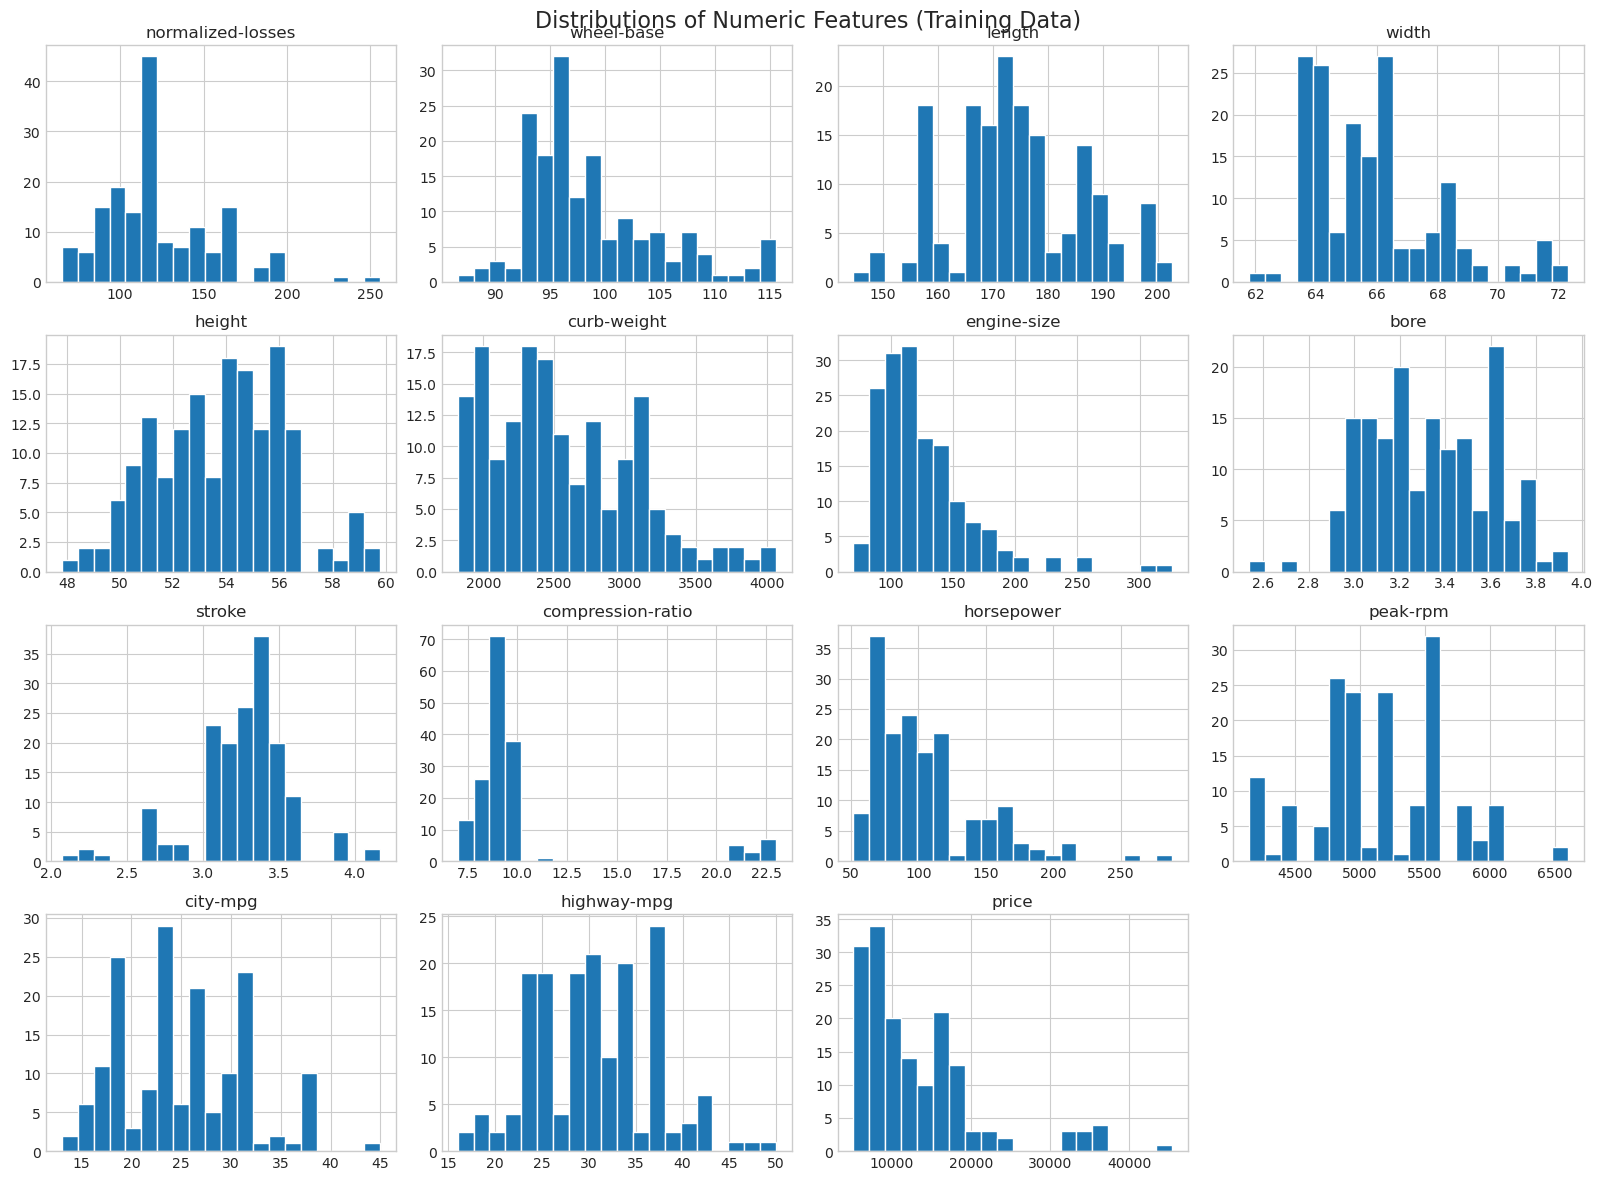

In [9]:
# Use numeric features for imputation plus 'price' for the histograms
numeric_cols_for_eda = numeric_features_for_imputation + ['price']

# Histogram of all numeric variables (training data only)
train_data[numeric_cols_for_eda].hist(figsize=(16, 12), bins=20)
plt.tight_layout()
plt.suptitle("Distributions of Numeric Features (Training Data)", fontsize=16)
plt.subplots_adjust(top=0.95)
plt.show()

### Car Makes Analysis

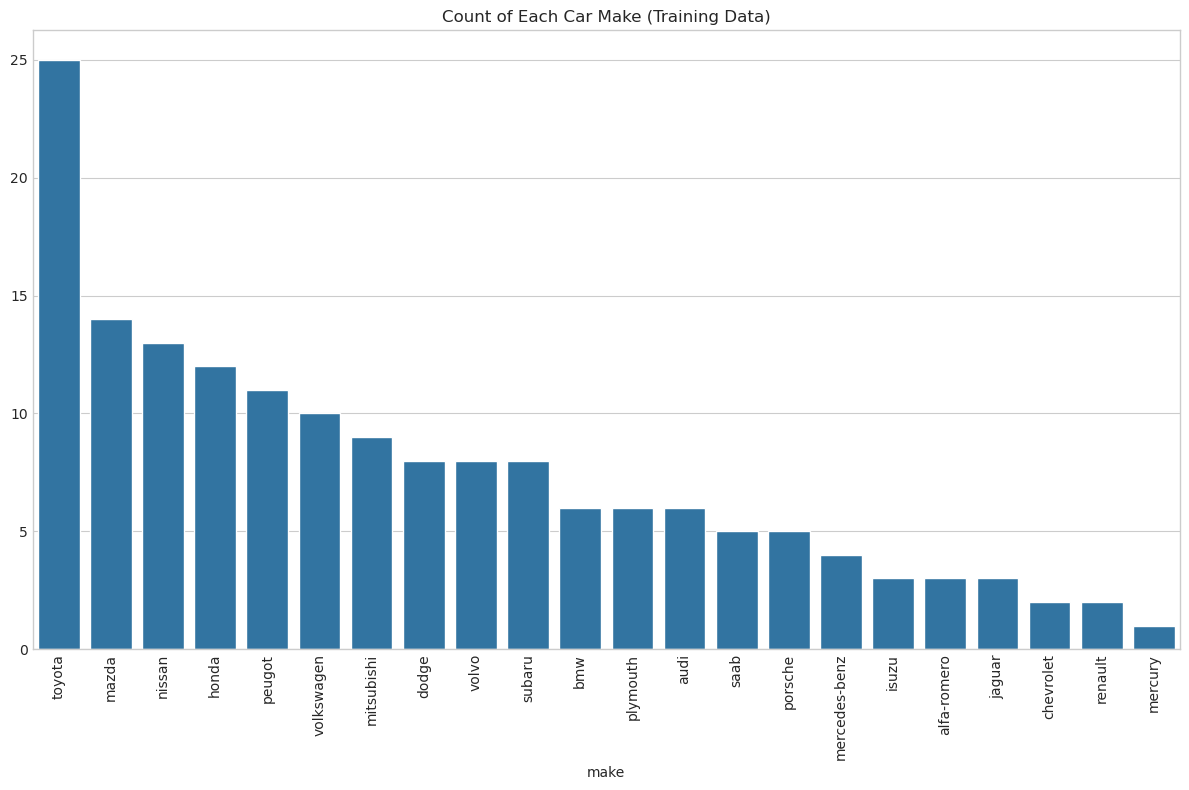

In [10]:
# Count of each car make (training data only)
plt.figure(figsize=(12, 8))
count_make = train_data['make'].value_counts()
sns.barplot(x=count_make.index, y=count_make.values)
plt.title('Count of Each Car Make (Training Data)')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

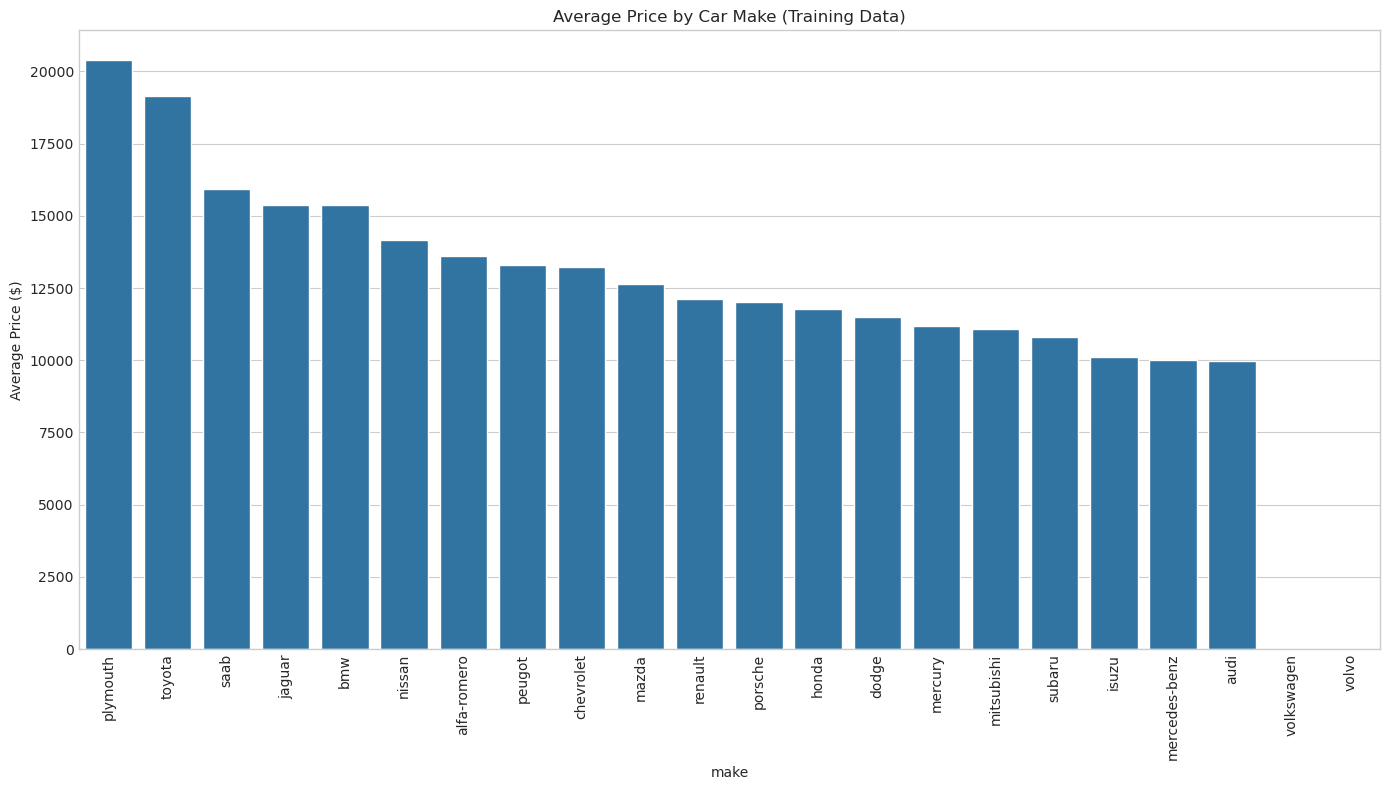

In [11]:
# Average price by make (training data only)
plt.figure(figsize=(14, 8))
avg_price = train_data.groupby('make')['price'].mean().sort_values(ascending=False)
sns.barplot(x=avg_price.index, y=avg_price.values)
plt.title('Average Price by Car Make (Training Data)')
plt.xticks(rotation=90)
plt.ylabel('Average Price ($)')
plt.tight_layout()
plt.show()

### Price Analysis

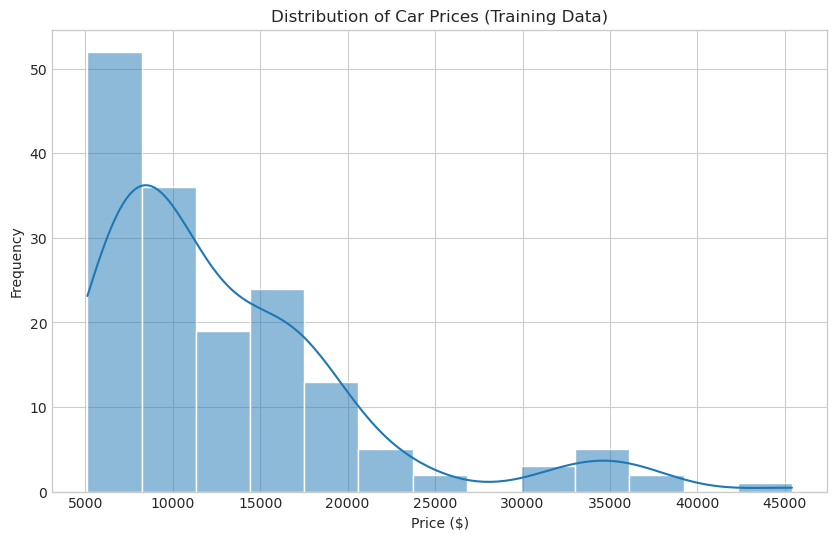

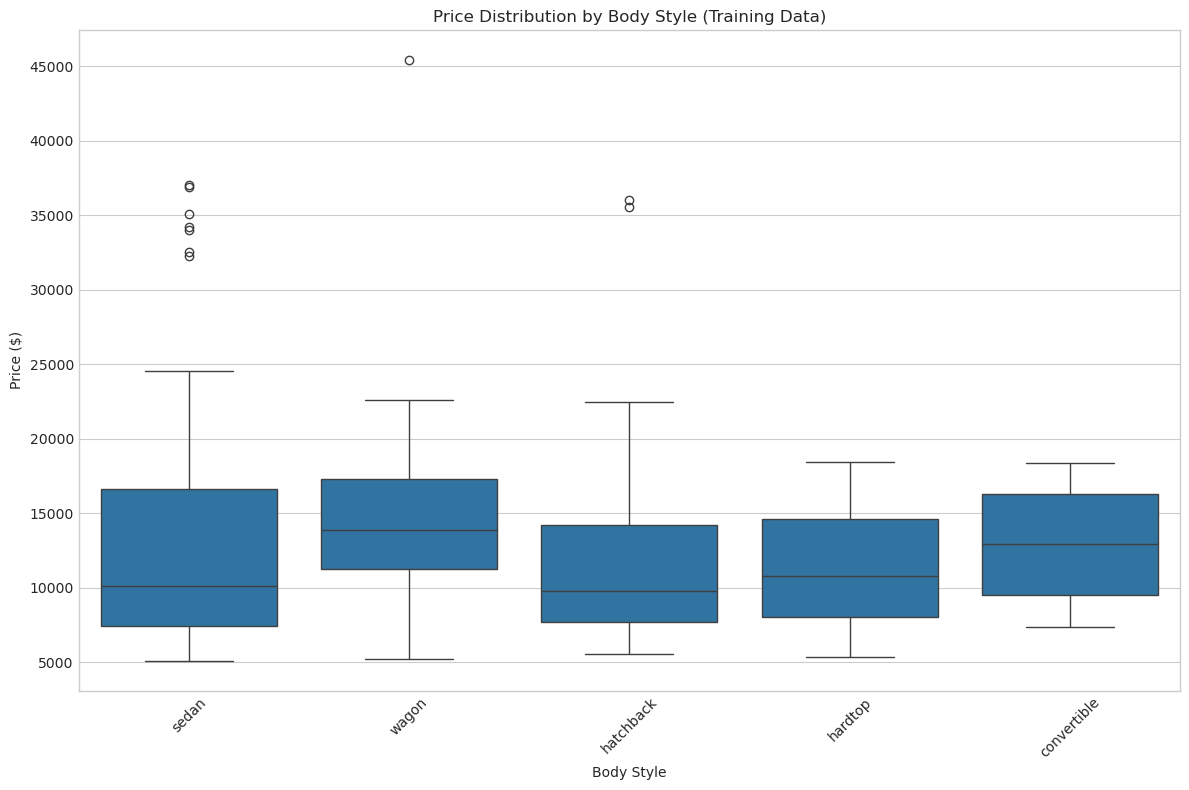

In [12]:
# Distribution of Price (training data only)
plt.figure(figsize=(10, 6))
sns.histplot(train_data['price'], kde=True)
plt.title('Distribution of Car Prices (Training Data)')
plt.xlabel('Price ($)')
plt.ylabel('Frequency')
plt.show()

# Box plot of price by body style (training data only)
plt.figure(figsize=(12, 8))
sns.boxplot(x='body-style', y='price', data=train_data)
plt.title('Price Distribution by Body Style (Training Data)')
plt.xlabel('Body Style')
plt.ylabel('Price ($)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Correlation Analysis

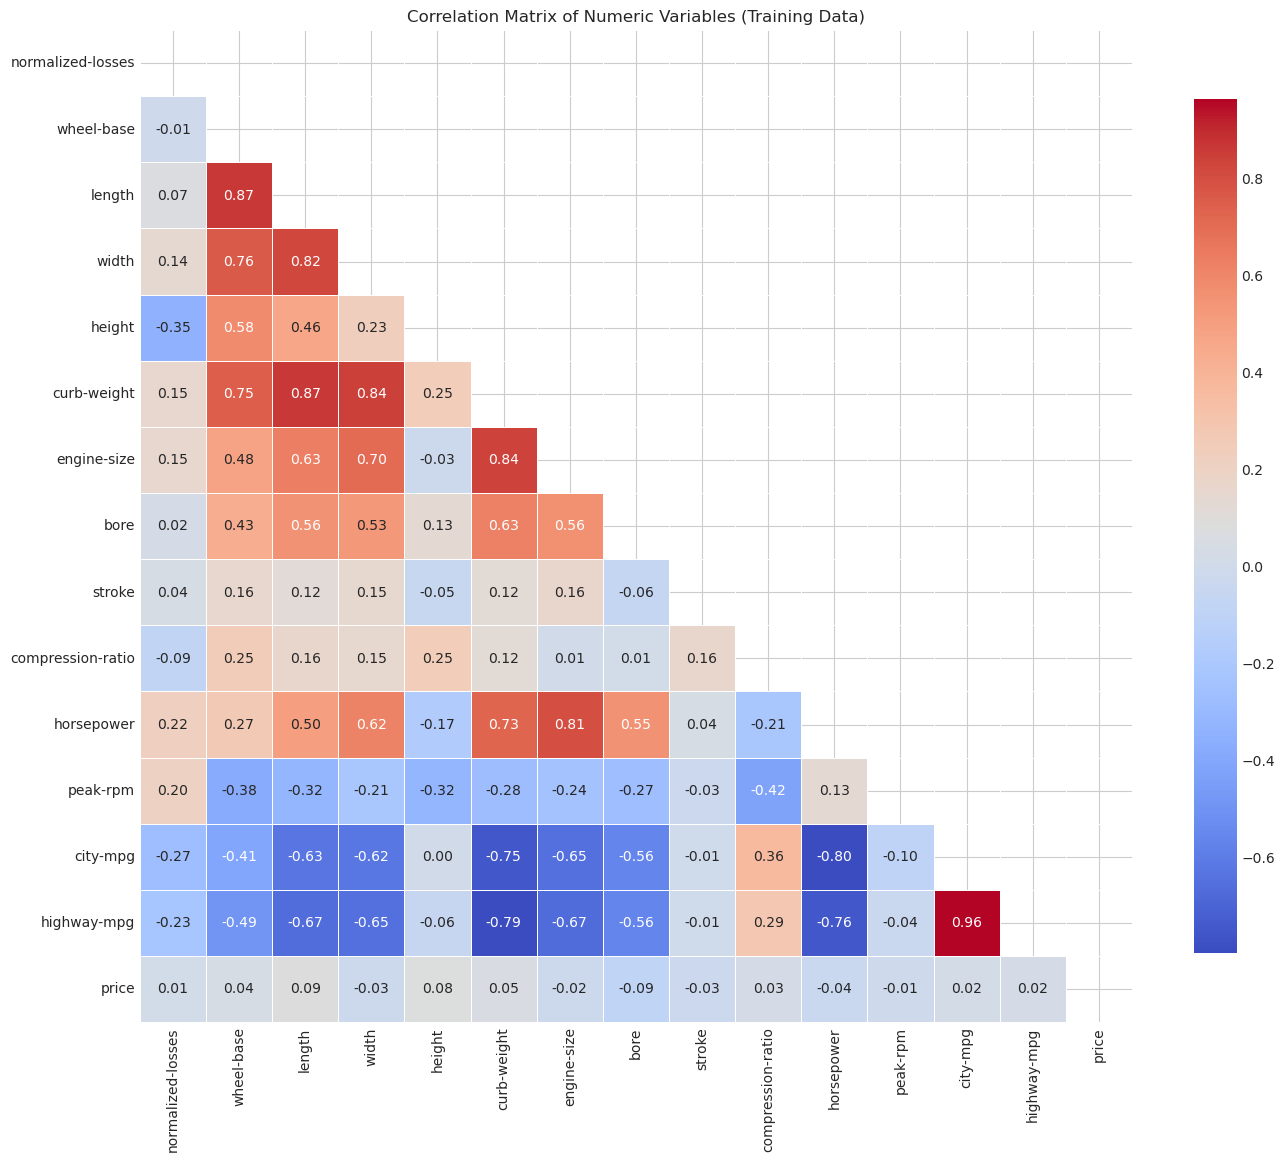

In [13]:
# Calculate correlation matrix for numeric variables (training data only)
corr_matrix = train_data[numeric_cols_for_eda].corr()

# Plot correlation heatmap
plt.figure(figsize=(14, 12))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm', 
            square=True, linewidths=.5, cbar_kws={'shrink': .8})
plt.title('Correlation Matrix of Numeric Variables (Training Data)')
plt.tight_layout()
plt.show()

### Key Feature Relationships

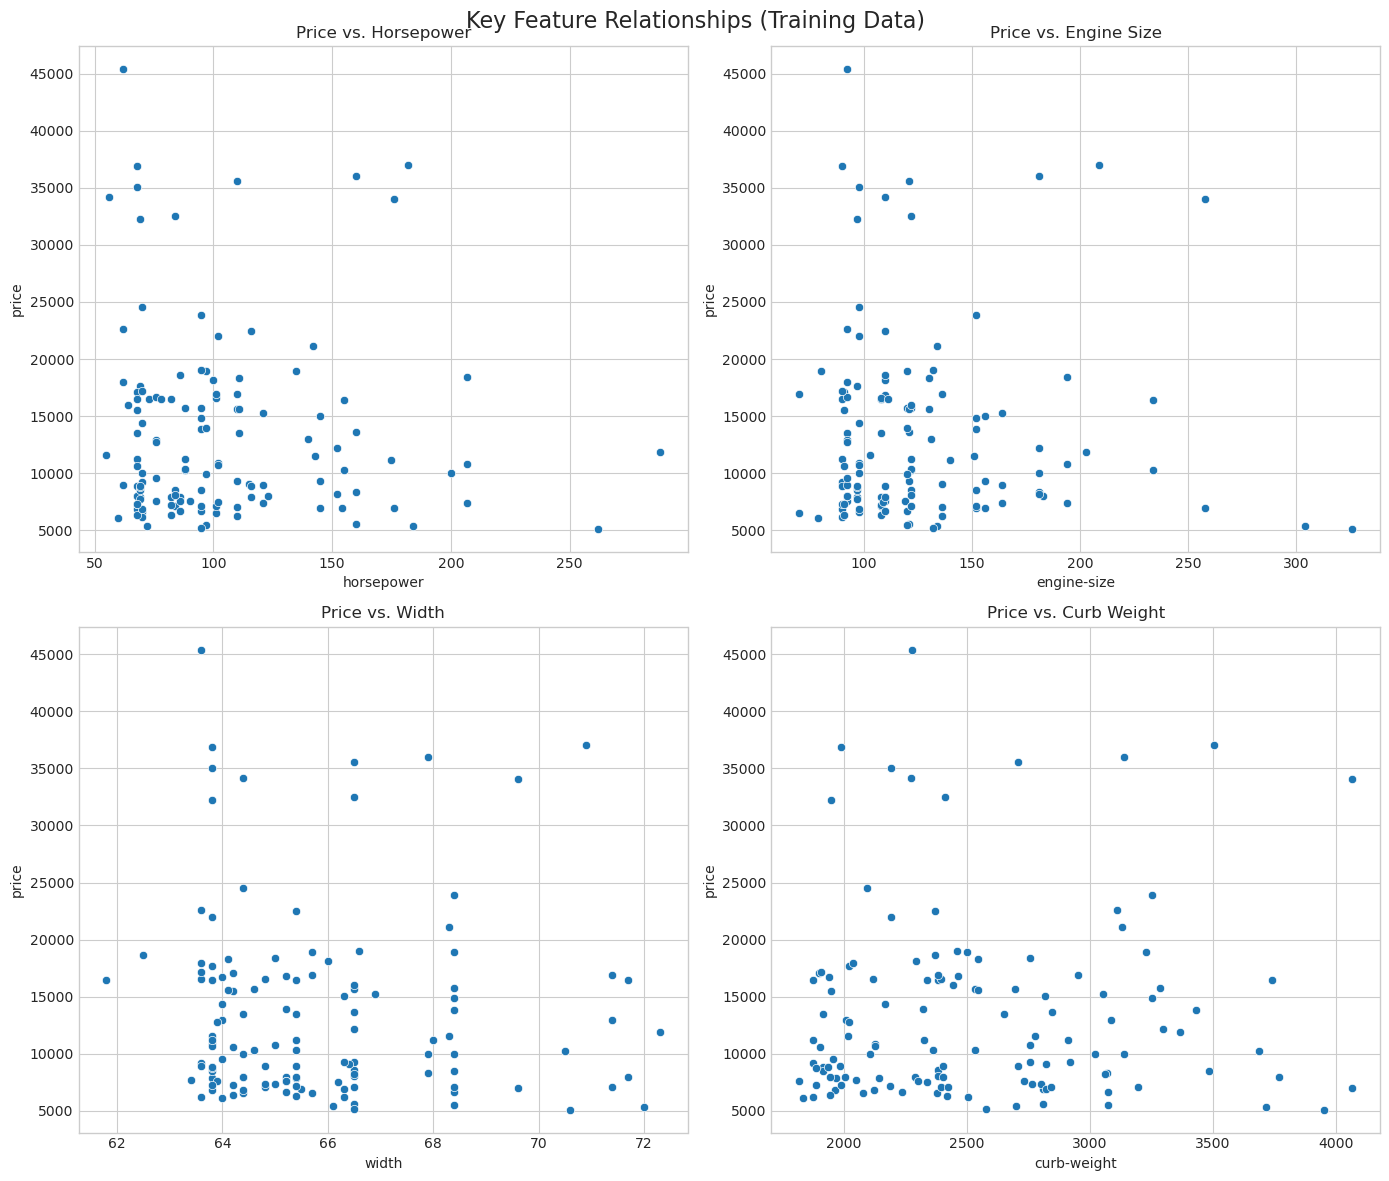

In [14]:
# Scatter plots for key feature relationships (training data only)
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# Price vs. horsepower
sns.scatterplot(x='horsepower', y='price', data=train_data, ax=axes[0, 0])
axes[0, 0].set_title('Price vs. Horsepower')

# Price vs. engine-size
sns.scatterplot(x='engine-size', y='price', data=train_data, ax=axes[0, 1])
axes[0, 1].set_title('Price vs. Engine Size')

# Price vs. width
sns.scatterplot(x='width', y='price', data=train_data, ax=axes[1, 0])
axes[1, 0].set_title('Price vs. Width')

# Price vs. curb-weight
sns.scatterplot(x='curb-weight', y='price', data=train_data, ax=axes[1, 1])
axes[1, 1].set_title('Price vs. Curb Weight')

plt.suptitle("Key Feature Relationships (Training Data)", fontsize=16)
plt.tight_layout()
plt.subplots_adjust(top=0.95)
plt.show()

### Specific Analysis of Width and Horsepower

Based on the 'misc' file, there seems to be a special interest in the relationship between width and horsepower.

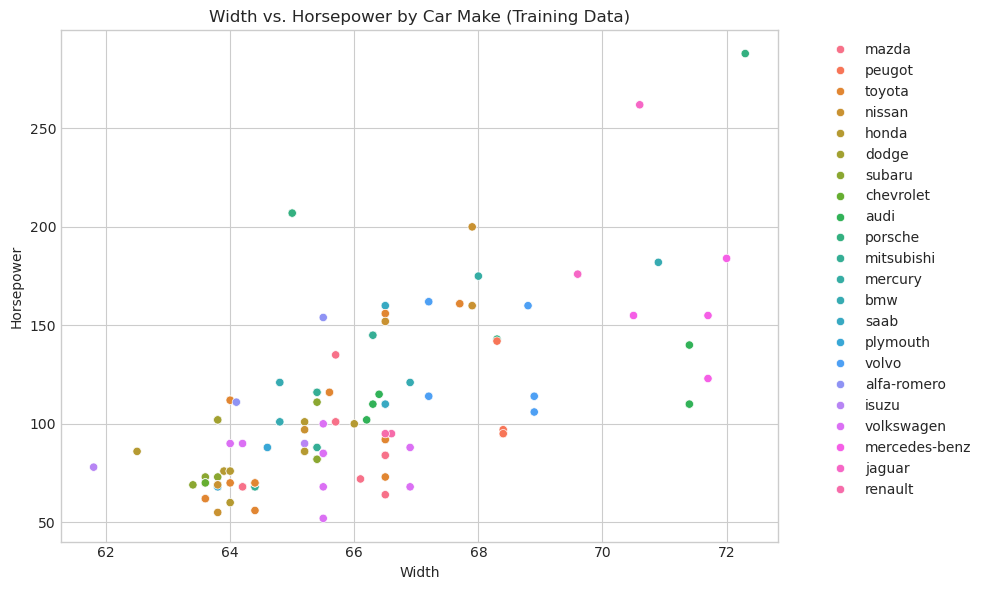

In [15]:
# Scatter plot with width and horsepower (training data only)
plt.figure(figsize=(10, 6))
sns.scatterplot(x='width', y='horsepower', data=train_data, hue='make')
plt.title('Width vs. Horsepower by Car Make (Training Data)')
plt.xlabel('Width')
plt.ylabel('Horsepower')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

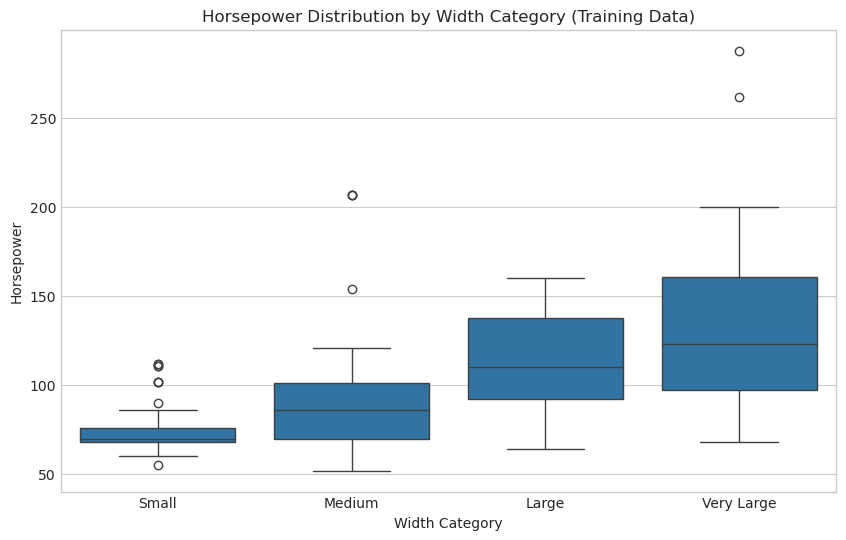

In [16]:
# Compare horsepower across different width ranges (training data only)
train_data['width_category'] = pd.qcut(train_data['width'], 4, labels=['Small', 'Medium', 'Large', 'Very Large'])

plt.figure(figsize=(10, 6))
sns.boxplot(x='width_category', y='horsepower', data=train_data)
plt.title('Horsepower Distribution by Width Category (Training Data)')
plt.xlabel('Width Category')
plt.ylabel('Horsepower')
plt.show()

## Feature Engineering

We'll create new features based on our understanding of the data, keeping the training/test separation intact.

In [17]:
# Create feature engineering functions to apply to both training and test sets
def engineer_features(df):
    """Apply feature engineering to the dataset"""
    # Create a power-to-weight ratio feature
    df['power_to_weight'] = df['horsepower'] / df['curb-weight']
    
    # Create a feature for engine size per cylinder
    # First, convert num-of-cylinders to numeric
    cylinder_map = {
        'two': 2,
        'three': 3,
        'four': 4,
        'five': 5,
        'six': 6,
        'eight': 8,
        'twelve': 12
    }
    df['num_cylinders'] = df['num-of-cylinders'].map(cylinder_map)
    df['engine_size_per_cylinder'] = df['engine-size'] / df['num_cylinders']
    
    # Create fuel efficiency feature (combined MPG)
    df['combined_mpg'] = (df['city-mpg'] + df['highway-mpg']) / 2
    
    return df

# Apply feature engineering to both sets
X_train = engineer_features(X_train)
X_test = engineer_features(X_test)

# Update training data for continued analysis
train_data = pd.concat([X_train, y_train.reset_index(drop=True)], axis=1)

# Display new features
train_data[['power_to_weight', 'engine_size_per_cylinder', 'combined_mpg']].describe()

,power_to_weight,engine_size_per_cylinder,combined_mpg
count,164.000000,164.000000,164.000000
mean,0.040340,28.735620,27.823171
std,0.009958,4.935379,6.244444
min,0.019936,19.750000,15.000000
25%,0.034370,24.500000,22.375000
50%,0.037961,27.500000,27.000000
75%,0.044070,30.500000,32.000000
max,0.085561,43.000000,47.500000


## Preparing for Machine Learning

Now we'll prepare our data for machine learning by encoding categorical variables and scaling numeric features, maintaining our train/test separation.

In [18]:
# Identify feature types
numeric_features = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X_train.select_dtypes(include=['object']).columns.tolist()

# Remove width_category created during EDA if it exists
if 'width_category' in X_train.columns:
    X_train = X_train.drop('width_category', axis=1)
if 'width_category' in X_test.columns:
    X_test = X_test.drop('width_category', axis=1)

# Update feature lists if needed
if 'width_category' in numeric_features:
    numeric_features.remove('width_category')
if 'width_category' in categorical_features:
    categorical_features.remove('width_category')

In [19]:
# Create preprocessing pipelines
numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('onehot', pd.get_dummies)
])

# Apply one-hot encoding to categorical features
X_train_cat = pd.get_dummies(X_train[categorical_features], drop_first=True)
X_test_cat = pd.get_dummies(X_test[categorical_features], drop_first=True)

# Ensure test set has the same columns as train set
missing_cols = set(X_train_cat.columns) - set(X_test_cat.columns)
for col in missing_cols:
    X_test_cat[col] = 0
X_test_cat = X_test_cat[X_train_cat.columns]

# Scale numeric features
scaler = StandardScaler()
X_train_num = pd.DataFrame(scaler.fit_transform(X_train[numeric_features]), 
                         columns=numeric_features, 
                         index=X_train.index)
X_test_num = pd.DataFrame(scaler.transform(X_test[numeric_features]), 
                        columns=numeric_features, 
                        index=X_test.index)

# Combine processed features
X_train_processed = pd.concat([X_train_num, X_train_cat], axis=1)
X_test_processed = pd.concat([X_test_num, X_test_cat], axis=1)

print(f"Processed training data shape: {X_train_processed.shape}")
print(f"Processed test data shape: {X_test_processed.shape}")

Processed training data shape: (164, 68)
Processed test data shape: (41, 68)


In [20]:
# View sample of processed data
X_train_processed.head()

,symboling,normalized-losses,wheel-base,length,width,height,curb-weight,engine-size,bore,stroke,...,num-of-cylinders_six,num-of-cylinders_twelve,num-of-cylinders_two,fuel-system_2bbl,fuel-system_4bbl,fuel-system_idi,fuel-system_mfi,fuel-system_mpfi,fuel-system_spdi,fuel-system_spfi
66,-0.727380,-0.144594,1.037085,0.072450,0.083817,0.276779,0.281287,0.188010,0.407195,1.212947,...,False,False,False,False,False,True,False,False,False,False
111,-0.727380,1.164362,1.541231,1.043916,1.170268,1.207269,1.016045,-0.158993,0.518743,-3.361816,...,False,False,False,False,False,False,False,True,False,False
153,-0.727380,-1.392668,-0.508962,-0.367616,-1.097108,2.178216,-0.541642,-0.852999,-1.005745,-0.711608,...,False,False,False,True,False,False,False,False,False,False
96,0.078636,-0.022831,-0.710620,-0.732953,-1.002634,0.317235,-1.147082,-0.729070,-0.633918,0.108694,...,False,False,False,True,False,False,False,False,False,False
38,-0.727380,-0.509884,-0.374523,-0.550285,-0.341316,-0.168238,-0.524008,-0.406852,-0.633918,1.023647,...,False,False,False,False,False,False,False,False,False,False
